In [6]:
# CELL 1: Environment Setup & GPU Verification
# Aligns with Handbook: Section 7 (Implementation Details), AI Core Requirement

import os
import torch
import torchvision
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
import shutil

# 1. Verify GPU availability (required for fast training on free Colab)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔧 Using device: {device}")
assert torch.cuda.is_available(), "⚠️ Switch Colab Runtime to GPU: Runtime > Change runtime type > Hardware accelerator > GPU"

# 2. Install minimal dependencies (lightweight to avoid Colab timeout)
!pip install -q streamlit opencv-python-headless grad-cam kaggle

# 3. Create clean project structure
for d in ["dataset/images", "models", "output"]:
    os.makedirs(d, exist_ok=True)

    print("✅ Environment ready. Proceed to next cell when prompted.")

🔧 Using device: cuda
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 117.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
✅ Environment ready. Proceed to next cell when prompted.
✅ Environment ready. Proceed to next cell when prompted.
✅ Environment ready. Proceed to next cell when prompted.


In [7]:
# CELL 2: Dataset Download & Binary Label Prep (CORRECTED)
# Aligns with Handbook Section 5: Data Description

import os
import shutil
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import kagglehub

# 1. Download HAM10000 dataset (Standard Image + Metadata version)
print("⬇️ Downloading HAM10000 dataset...")
try:
    dataset_path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
    print(f"✅ Dataset cached at: {dataset_path}")
except Exception as e:
    print(f"⚠️ KaggleHub failed: {e}")
    raise

# 2. Locate Metadata (Target ham10000_metadata.csv specifically)
meta_file = "HAM10000_metadata.csv"
meta_path = None
for root, _, files in os.walk(dataset_path):
    if meta_file in files:
        meta_path = os.path.join(root, meta_file)
        break

if not meta_path:
    raise FileNotFoundError(f"❌ Could not find {meta_file}.")

print(f" Found Metadata: {meta_path}")
df = pd.read_csv(meta_path)
print(f" Metadata Loaded: {len(df)} rows. Columns: {list(df.columns)[:5]}...")

# 3. Locate Images (Recursively find all .jpg files)
img_map = {}
img_dir = "dataset/images"
os.makedirs(img_dir, exist_ok=True)

print(" Scanning for images...")
for root, _, files in os.walk(dataset_path):
    for f in files:
        if f.lower().endswith(('.jpg', '.jpeg')):
            src = os.path.join(root, f)
            dest = os.path.join(img_dir, f)
            if not os.path.exists(dest):
                shutil.copy(src, dest)
            img_map[f] = dest

print(f"✅ Found {len(img_map)} images.")

# 4. Create Binary Labels using 'dx' column
# Valid dermatological codes
valid_dx = {'nv', 'bkl', 'df', 'mel', 'bcc', 'akiec', 'vasc'}
benign_dx = {'nv', 'bkl', 'df'}
suspicious_dx = {'mel', 'bcc', 'akiec', 'vasc'}

def map_binary(dx):
    dx = str(dx).lower().strip()
    if dx not in valid_dx:
        return None # Filter out unknowns
    if dx in benign_dx:
        return 'Benign'
    return 'Suspicious'

df['binary_label'] = df['dx'].apply(map_binary)
df = df.dropna(subset=['binary_label']).copy() # Remove rows with invalid labels
df['label'] = df['binary_label'].map({'Benign': 0, 'Suspicious': 1})

# 5. Link Metadata to Image Files
df['image_id'] = df['image_id'].astype(str)
df['image_file'] = df['image_id'].apply(lambda x: x + ".jpg")

# Ensure we have images for these rows
df['file_exists'] = df['image_file'].apply(lambda x: x in img_map)
df = df[df['file_exists']].copy()

print(f"\n🧹 Filtered Dataset Size: {len(df)}")
print(f"   Benign (0): {(df['label']==0).sum()}")
print(f"   Suspicious (1): {(df['label']==1).sum()}")

# 6. Train/Val/Test split (80/10/10) - stratified
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

# Save lightweight CSVs for DataLoader
train_df[['image_id', 'label']].to_csv("dataset/train.csv", index=False)
val_df[['image_id', 'label']].to_csv("dataset/val.csv", index=False)
test_df[['image_id', 'label']].to_csv("dataset/test.csv", index=False)

print("\n✅ Dataset prepared successfully.")
print(f"   Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

⬇️ Downloading HAM10000 dataset...
Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
✅ Dataset cached at: /kaggle/input/skin-cancer-mnist-ham10000
 Found Metadata: /kaggle/input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv
 Metadata Loaded: 10015 rows. Columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age']...
 Scanning for images...
✅ Found 10015 images.

🧹 Filtered Dataset Size: 10015
   Benign (0): 7919
   Suspicious (1): 2096

✅ Dataset prepared successfully.
   Train: 8012, Val: 1001, Test: 1002


In [8]:
# CELL 3: DataLoader + EfficientNet-B0 Model Setup
# Aligns with Handbook Sections 4, 6, 7

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import pandas as pd
import os
from torch.cuda.amp import GradScaler, autocast  # Mixed precision for speed

# 1. Custom Dataset Class
class SkinLesionDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = f"{self.df.iloc[idx]['image_id']}.jpg"
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        label = self.df.iloc[idx]['label']

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)

# 2. Define Transforms (Handbook Section 5: Preprocessing)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# 3. Create DataLoaders
train_dataset = SkinLesionDataset("dataset/train.csv", "dataset/images", transform=train_transform)
val_dataset = SkinLesionDataset("dataset/val.csv", "dataset/images", transform=val_transform)
test_dataset = SkinLesionDataset("dataset/test.csv", "dataset/images", transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

print(f"✅ DataLoaders created:")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches:   {len(val_loader)}")
print(f"   Test batches:  {len(test_loader)}")

# 4. Load EfficientNet-B0 (Handbook Section 4: Model Architecture)
print("\n⚙️ Loading EfficientNet-B0...")
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# Freeze backbone (transfer learning - Handbook Section 4)
for param in model.features.parameters():
    param.requires_grad = False

# Replace classifier for binary output
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 1)

# Ensure 'device' is defined globally (e.g., from an earlier cell)
# Assuming 'device' is available from CELL 1
model = model.to(device)

# 5. Loss, Optimizer, Scheduler (Handbook Section 4: Training Approach)
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([2.5]).to(device))  # Handle class imbalance
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# 6. Mixed Precision Scaler (Speed optimization)
scaler = GradScaler()

print("✅ Model ready for training.")
print(f"   Architecture: EfficientNet-B0 (frozen backbone)")
print(f"   Classifier: Linear({num_features} → 1)")
print(f"   Loss: BCEWithLogitsLoss (weighted for imbalance)")
print(f"   Optimizer: Adam (lr=1e-3)")
print(f"   Mixed Precision: Enabled")

✅ DataLoaders created:
   Train batches: 501
   Val batches:   63
   Test batches:  63

⚙️ Loading EfficientNet-B0...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 192MB/s]


✅ Model ready for training.
   Architecture: EfficientNet-B0 (frozen backbone)
   Classifier: Linear(1280 → 1)
   Loss: BCEWithLogitsLoss (weighted for imbalance)
   Optimizer: Adam (lr=1e-3)
   Mixed Precision: Enabled


/tmp/ipykernel_6893/2205012212.py:89: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


🎯 Starting training: 10 epochs, early stopping patience=3
   Device: cuda
Epoch 1/10 | Train Loss: 0.6975 | Val Loss: 0.6592 | Val Acc: 73.03% | Time: 88.9s
   💾 Saved best model (val_loss: 0.6592)
Epoch 2/10 | Train Loss: 0.6373 | Val Loss: 0.6342 | Val Acc: 74.73% | Time: 86.1s
   💾 Saved best model (val_loss: 0.6342)
Epoch 3/10 | Train Loss: 0.6311 | Val Loss: 0.6291 | Val Acc: 76.02% | Time: 84.6s
   💾 Saved best model (val_loss: 0.6291)
Epoch 4/10 | Train Loss: 0.6199 | Val Loss: 0.6130 | Val Acc: 77.32% | Time: 85.9s
   💾 Saved best model (val_loss: 0.6130)
Epoch 5/10 | Train Loss: 0.6193 | Val Loss: 0.6114 | Val Acc: 77.92% | Time: 86.5s
   💾 Saved best model (val_loss: 0.6114)
Epoch 6/10 | Train Loss: 0.6269 | Val Loss: 0.6167 | Val Acc: 77.72% | Time: 86.1s
Epoch 7/10 | Train Loss: 0.6268 | Val Loss: 0.6137 | Val Acc: 77.82% | Time: 87.5s
Epoch 8/10 | Train Loss: 0.6105 | Val Loss: 0.6280 | Val Acc: 77.22% | Time: 86.0s
⏹️ Early stopping triggered at epoch 8

✅ Training comple

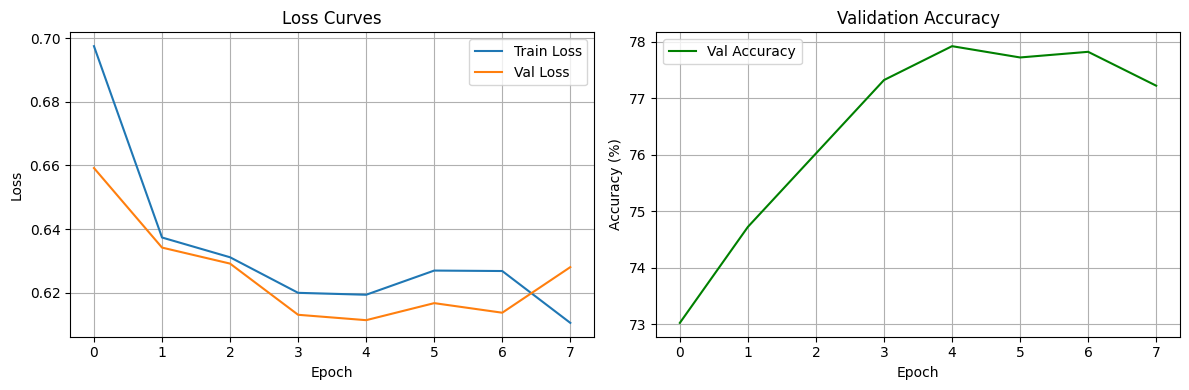

In [9]:
# CELL 4: Training Loop (Simplified - No Mixed Precision)
# Aligns with Handbook Sections 4, 6, 7

import time
import matplotlib.pyplot as plt

# Training config
NUM_EPOCHS = 10
PATIENCE = 3  # Early stopping patience
best_val_loss = float('inf')
epochs_no_improve = 0
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

print(f"🎯 Starting training: {NUM_EPOCHS} epochs, early stopping patience={PATIENCE}")
print(f"   Device: {device}")

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    # === TRAINING PHASE ===
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        # Forward pass (no autocast)
        outputs = model(images).squeeze()
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    # === VALIDATION PHASE ===
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images).squeeze()
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            # Binary accuracy
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct / total

    # Update scheduler
    scheduler.step(val_loss)

    # Record history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    epoch_time = time.time() - start_time

    # === LOGGING ===
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_acc:.2f}% | "
          f"Time: {epoch_time:.1f}s")

    # === EARLY STOPPING + SAVE BEST ===
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "models/best_model.pt")
        epochs_no_improve = 0
        print(f"   💾 Saved best model (val_loss: {best_val_loss:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"⏹️ Early stopping triggered at epoch {epoch+1}")
            break

# === FINAL SUMMARY ===
print("\n✅ Training complete!")
print(f"   Best Val Loss: {best_val_loss:.4f}")
print(f"   Best Val Acc: {max(history['val_acc']):.2f}%")
print(f"   Model saved to: models/best_model.pt")

# === PLOT TRAINING CURVES ===
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curves')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['val_acc'], label='Val Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("output/training_curves.png", dpi=150)
print("📊 Training curves saved to output/training_curves.png")

In [ ]:
# CELL 5: Launch Streamlit Demo with LocalTunnel (No Auth Required)

# 1. Create app.py
app_code = '''import streamlit as st
import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image
import os

st.set_page_config(page_title="Skin Lesion Triage", page_icon="", layout="centered")
st.title("🩺 Skin Lesion Triage Assistant")
st.markdown("**AI-powered early screening for primary care clinics**")

if not os.path.exists("models/best_model.pt"):
    st.error("❌ Model not found!")
    st.stop()

@st.cache_resource
def load_model():
    model = models.efficientnet_b0(weights=None)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, 1)
    model.load_state_dict(torch.load("models/best_model.pt", map_location="cpu", weights_only=True))
    model.eval()
    return model

def preprocess_image(image):
    return transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])(image).unsqueeze(0)

uploaded_file = st.file_uploader("Upload image", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    col1, col2 = st.columns(2)
    with col1:
        st.subheader("Uploaded Image")
        image = Image.open(uploaded_file).convert("RGB")
        st.image(image, use_column_width=True)

    with st.spinner("Analyzing..."):
        model = load_model()
        img_tensor = preprocess_image(image)
        with torch.no_grad():
            prob = torch.sigmoid(model(img_tensor)).item()

        pred = "Suspicious" if prob > 0.5 else "Benign"
        conf = (prob if prob > 0.5 else 1 - prob) * 100

    with col2:
        st.subheader("AI Assessment")
        if pred == "Suspicious":
            st.error(f"🚨 Result: SUSPICIOUS")
            st.error(f"Confidence: {conf:.1f}%")
            st.error("Refer to dermatologist")
        else:
            st.success(f"✅ Result: BENIGN")
            st.success(f"Confidence: {conf:.1f}%")
            st.success("Routine monitoring")

        st.progress(prob)
        st.caption(f"Risk Score: {prob*100:.1f}%")
else:
    st.info("👆 Upload an image")
'''

with open("app.py", "w") as f:
    f.write(app_code)
    print("✅ app.py created")

# 2. Install dependencies
!pip install -q streamlit
!npm install -g localtunnel 2>/dev/null
print("✅ Dependencies installed")

# 3. Kill old processes
!pkill -f streamlit 2>/dev/null
!pkill -f lt 2>/dev/null
print("✅ Cleaned up")

# 4. Start Streamlit in background
get_ipython().system_raw('streamlit run app.py &>/dev/null &')
print("✅ Streamlit started")

# 5. Wait and launch tunnel
import time
time.sleep(4)
print("\n🔗 Getting public link...")
!lt --port 8501

✅ app.py created

added 22 packages in 2s

3 packages are looking for funding
  run `npm fund` for details
✅ Dependencies installed
^C
^C
✅ Cleaned up
✅ Streamlit started

🔗 Getting public link...
your url is: https://nine-foxes-travel.loca.lt
